# Marketing A/B Test Analysis

## Project Overview

This project analyzes the performance of a digital advertising campaign using A/B testing.

Users were assigned to two experimental groups:

* **Ad:** Users exposed to the advertising campaign
* **PSA:** Control group exposed to a public service announcement

The primary objective is to determine whether exposure to the advertising campaign leads to a statistically significant difference in user conversion rate compared with the PSA control group.

### Key Business Questions

1. Does exposure to the advertising campaign change customer conversion compared with the control (PSA) group?
2. How large is the observed improvement?
3. Is the difference statistically significant?
4. What is the confidence interval for the treatment effect?
5. What is the practical effect size of the campaign?
6. How does statistical power affect the interpretation of the experiment?
7. Does conversion performance vary by day?
8. How does conversion rate vary with repeated advertising exposure?

### Primary Metric

The primary success metric is **conversion rate**:

$$
Conversion\ Rate =
\frac{Number\ of\ Conversions}{Number\ of\ Users}
$$

The analysis combines descriptive statistics, hypothesis testing, confidence intervals, effect-size analysis, statistical power, and segmentation by advertising exposure.

# 01 — Data Understanding & Cleaning

### Objective
Understand the structure, quality, and experimental setup of the marketing A/B testing dataset before performing statistical analysis.

In [3]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
df = pd.read_csv("../data/raw/marketing_AB.csv")

In [5]:
# Remove exported DataFrame index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape after cleaning:", df.shape)


Dataset shape after cleaning: (588101, 6)


In [6]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user id        588101 non-null  int64
 1   test group     588101 non-null  str  
 2   converted      588101 non-null  bool 
 3   total ads      588101 non-null  int64
 4   most ads day   588101 non-null  str  
 5   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(3), str(2)
memory usage: 23.0 MB


### Dataset Overview

The dataset contains **588,101 user-level observations** and **6 variables** after removing the exported DataFrame index column.

Each row represents a user and contains information about experimental group assignment, conversion outcome, total advertising exposure, and the day and hour with the highest ad exposure.

The dataset contains two experimental groups:

- **Ad:** Users exposed to the advertising campaign
- **PSA:** Users in the control group exposed to a public service announcement

The primary outcome variable is `converted`, which indicates whether a user completed the target conversion.

## 2. Data Quality Audit

Before performing any statistical analysis, we will check:

- Missing values
- Duplicate records
- Unique users
- Experimental groups
- Outcome values
- Numerical variable ranges

In [8]:
# Missing values
missing_values = df.isnull().sum()

# Duplicate rows
duplicate_rows = df.duplicated().sum()

print("Missing values by column:")
print(missing_values)

print(f"\nDuplicate rows: {duplicate_rows}")

Missing values by column:
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

Duplicate rows: 0


### Data Quality Result

No missing values or duplicate rows were found in the dataset. This means the dataset does not require imputation or duplicate-row removal before analysis.

In [9]:
# Validate user-level uniqueness
unique_users = df["user id"].nunique()
total_rows = len(df)

print(f"Total rows: {total_rows:,}")
print(f"Unique users: {unique_users:,}")
print(f"Duplicate user IDs: {total_rows - unique_users:,}")

Total rows: 588,101
Unique users: 588,101
Duplicate user IDs: 0


In [10]:
# Experimental group distribution
group_counts = df["test group"].value_counts()
group_share = df["test group"].value_counts(normalize=True) * 100

group_summary = pd.DataFrame({
    "users": group_counts,
    "share_pct": group_share
})

group_summary

,users,share_pct
test group,,
ad,564577,96.000007
psa,23524,3.999993


### Experimental Allocation

The experiment contains a highly imbalanced allocation, with approximately **96% of users in the Ad group and 4% in the PSA control group**.

The analysis therefore uses the observed group sizes rather than assuming a 50/50 allocation. The smaller PSA group should also be considered when interpreting uncertainty and experimental design.

In [11]:
# Conversion outcome distribution
conversion_counts = df["converted"].value_counts()
conversion_share = df["converted"].value_counts(normalize=True) * 100

conversion_summary = pd.DataFrame({
    "users": conversion_counts,
    "share_pct": conversion_share
})

conversion_summary

,users,share_pct
converted,,
False,573258,97.476114
True,14843,2.523886


### Conversion Outcome

The conversion variable is binary, containing only `True` and `False` outcomes. This makes it appropriate for comparing conversion proportions between the experimental groups.

### Numerical Variable Validation

We examine the distribution and range of advertising exposure and peak advertising hour.

In [12]:
# Numerical summary
df[["total ads", "most ads hour"]].describe()

,total ads,most ads hour
count,588101.000000,588101.000000
mean,24.820876,14.469061
std,43.715181,4.834634
min,1.000000,0.000000
25%,4.000000,11.000000
50%,13.000000,14.000000
75%,27.000000,18.000000
max,2065.000000,23.000000


## 3. Experimental Group Validation

Before estimating the treatment effect, we validate the allocation of users across the experimental groups.

The experiment contains two groups:

* **Ad:** Users exposed to the advertising campaign
* **PSA:** Control users exposed to the public service announcement

We first examine the observed allocation and conversion outcomes across the two experimental groups.

In [13]:
# Conversion outcomes by experimental group
group_conversion = pd.crosstab(
    df["test group"],
    df["converted"]
)

group_conversion

converted,False,True
test group,,
ad,550154,14423
psa,23104,420


In [14]:
# Conversion rate by experimental group
conversion_summary = (
    df.groupby("test group")["converted"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "users",
        "sum": "conversions",
        "mean": "conversion_rate"
    })
)

conversion_summary

,users,conversions,conversion_rate
test group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


In [15]:
# Convert rates to percentages
conversion_summary["conversion_rate_pct"] = (
    conversion_summary["conversion_rate"] * 100
)

conversion_summary[[
    "users",
    "conversions",
    "conversion_rate_pct"
]].round(2)

,users,conversions,conversion_rate_pct
test group,,,
ad,564577,14423,2.55
psa,23524,420,1.79


### Initial Group Comparison

The Ad group contains substantially more users than the PSA control group, with approximately 96% of users assigned to Ad and 4% to PSA.

The observed conversion rate is higher in the Ad group:

- **Ad:** 2.55%
- **PSA:** 1.79%

This represents an observed difference of approximately 0.77 percentage points.

However, the observed difference alone does not establish that advertising caused the improvement. Statistical testing is required to determine whether the difference is unlikely to be explained by sampling variation.

In [16]:
# Verify that each user belongs to exactly one experimental group
users_per_group = df.groupby("user id")["test group"].nunique()

print("Users assigned to multiple groups:", (users_per_group > 1).sum())

Users assigned to multiple groups: 0


### Assignment Consistency

Each user is associated with exactly one experimental group. No users appear across both the Ad and PSA groups, supporting the independence of the two observed groups for the primary comparison.

## 4. Observed Treatment Effect

Before conducting a hypothesis test, we quantify the observed difference between the treatment and control groups.

We will calculate:

- Control conversion rate
- Treatment conversion rate
- Absolute conversion-rate difference
- Relative conversion lift

In [17]:
# Extract conversion rates
control_rate = conversion_summary.loc["psa", "conversion_rate"]
treatment_rate = conversion_summary.loc["ad", "conversion_rate"]

# Absolute treatment effect
absolute_lift = treatment_rate - control_rate

# Relative treatment effect
relative_lift = (absolute_lift / control_rate) * 100

print(f"Control conversion rate:   {control_rate:.4%}")
print(f"Treatment conversion rate: {treatment_rate:.4%}")
print(f"Absolute difference:        {absolute_lift * 100:.3f} percentage points")
print(f"Relative lift:              {relative_lift:.2f}%")

Control conversion rate:   1.7854%
Treatment conversion rate: 2.5547%
Absolute difference:        0.769 percentage points
Relative lift:              43.09%


In [18]:
# Estimated additional conversions if the control-sized group
# experienced the observed treatment conversion rate
estimated_incremental_conversions = (
    treatment_rate - control_rate
) * conversion_summary.loc["psa", "users"]

print(
    f"Estimated incremental conversions at the observed rate difference: "
    f"{estimated_incremental_conversions:.0f}"
)

Estimated incremental conversions at the observed rate difference: 181


### Estimated Incremental Conversions

Applying the observed conversion-rate difference to the PSA group's sample size corresponds to approximately 181 additional conversions.

This is a standardized estimate used to illustrate the magnitude of the observed effect. It should not be interpreted as a causal estimate until statistical significance and experimental assumptions have been evaluated.

## Interpretation of the Observed Effect

The advertising group had a higher observed conversion rate than the PSA control group.

The Ad conversion rate was approximately **2.55%**, compared with **1.79%** for the PSA group. This corresponds to an absolute difference of approximately **0.77 percentage points** and a relative lift of approximately **43.09%**.

The observed difference indicates a higher conversion rate in the advertising group within this sample. However, the difference alone does not establish that advertising caused the improvement. A formal hypothesis test is therefore required to determine whether the observed difference is statistically distinguishable from sampling variation.

# 5. Experiment Design & Hypothesis Testing

## Business Question

## Business Question

Does exposure to the advertising campaign change customer conversion compared with the control (PSA) group?

## Experimental Groups

- **Control:** PSA
- **Treatment:** Advertisement

## Primary Metric

The primary metric is conversion rate:

$$
p = \frac{\text{number of conversions}}{\text{number of users}}
$$

## Null Hypothesis

$$
H_0: p_{treatment} = p_{control}
$$

There is no difference in conversion probability between the treatment and control groups.

## Alternative Hypothesis

$$
H_1: p_{treatment} \neq p_{control}
$$

There is a difference in conversion probability between the two groups.

## Significance Level

We use:

$$
\alpha = 0.05
$$

This corresponds to a 95% confidence level.

## Statistical Test

Because:

- the outcome is binary (converted / not converted),
- we are comparing two independent groups, and
- we are comparing conversion proportions between two independent groups

we will use a **two-proportion z-test**.

## 5.1 Test Assumptions

For the normal approximation used by the two-proportion z-test, we need sufficiently large expected counts of successes and failures in both groups.

We will verify:

- $n_T p_T$
- $n_T(1-p_T)$
- $n_C p_C$
- $n_C(1-p_C)$

where $p$ represents the relevant group conversion rate.

In [19]:
# Sample sizes
n_treatment = conversion_summary.loc["ad", "users"]
n_control = conversion_summary.loc["psa", "users"]

# Conversion counts
x_treatment = conversion_summary.loc["ad", "conversions"]
x_control = conversion_summary.loc["psa", "conversions"]

# Pooled conversion rate under H0
pooled_rate = (
    (x_treatment + x_control)
    / (n_treatment + n_control)
)

print(f"Pooled conversion rate: {pooled_rate:.4%}")

Pooled conversion rate: 2.5239%


In [20]:
# Pooled conversion rate under H0
pooled_rate = (
    x_treatment + x_control
) / (
    n_treatment + n_control
)

In [21]:
# Expected counts under the null hypothesis
# H0 assumes both groups have the same conversion probability.

expected_counts = {
    "Treatment successes": n_treatment * pooled_rate,
    "Treatment failures": n_treatment * (1 - pooled_rate),
    "Control successes": n_control * pooled_rate,
    "Control failures": n_control * (1 - pooled_rate)
}

expected_counts = pd.Series(expected_counts)

expected_counts

Treatment successes     14249.28101
Treatment failures     550327.71899
Control successes         593.71899
Control failures        22930.28101
dtype: float64

## 6. Two-Proportion Z-Test

### Step 1 — Pooled Proportion

Under the null hypothesis, we assume that the treatment and control groups have the same underlying conversion probability.

The pooled proportion combines the conversion outcomes from both groups:

$$
\hat{p}_{pooled} =
\frac{x_T+x_C}{n_T+n_C}
$$

In [22]:
# Pooled conversion rate under H0
pooled_rate = (
    (x_treatment + x_control)
    / (n_treatment + n_control)
)

print(f"Pooled conversion rate: {pooled_rate:.4%}")

Pooled conversion rate: 2.5239%


### Step 2 — Standard Error

The standard error estimates how much the difference between the two sample proportions would naturally vary from sample to sample if the null hypothesis were true.

$$
SE =
\sqrt{
\hat{p}_{pooled}(1-\hat{p}_{pooled})
\left(
\frac{1}{n_T}+\frac{1}{n_C}
\right)
}
$$

In [23]:
# Standard error under the null hypothesis
standard_error = np.sqrt(
    pooled_rate * (1 - pooled_rate)
    * (1 / n_treatment + 1 / n_control)
)

print(f"Standard error: {standard_error:.6f}")

Standard error: 0.001044


### Step 3 — Z-Statistic

The z-statistic standardizes the observed difference between the treatment and control conversion rates.

$$
z =
\frac{p_T-p_C}{SE}
$$

A large absolute z-statistic means that the observed difference is large relative to the amount of variation we would expect under the null hypothesis.

In [24]:
# Observed conversion rates
p_treatment = x_treatment / n_treatment
p_control = x_control / n_control

# Z-statistic
z_statistic = (
    (p_treatment - p_control)
    / standard_error
)

print(f"Treatment conversion rate: {p_treatment:.4%}")
print(f"Control conversion rate: {p_control:.4%}")
print(f"Z-statistic: {z_statistic:.4f}")

Treatment conversion rate: 2.5547%
Control conversion rate: 1.7854%
Z-statistic: 7.3701


In [25]:
# Z-statistic
z_statistic = (
    (p_treatment - p_control)
    / standard_error
)

print(f"Z-statistic: {z_statistic:.4f}")

Z-statistic: 7.3701


In [26]:
from scipy import stats

p_value_manual = 2 * stats.norm.sf(abs(z_statistic))

print(f"Two-sided p-value: {p_value_manual:.3e}")

Two-sided p-value: 1.705e-13


In [27]:
manual_results = pd.DataFrame({
    "Metric": [
        "Pooled conversion rate",
        "Standard error",
        "Z-statistic",
        "P-value"
    ],
    "Value": [
        f"{pooled_rate:.4%}",
        f"{standard_error:.6f}",
        f"{z_statistic:.4f}",
        f"{p_value_manual:.3e}"
    ]
})

manual_results

,Metric,Value
0,Pooled conversion rate,2.5239%
1,Standard error,0.001044
2,Z-statistic,7.3701
3,P-value,1.705e-13


## 6.1 Verification Using Statsmodels

The manual calculation above will be independently verified using the `statsmodels` implementation of the two-proportion z-test.

The library result should match our manually calculated z-statistic and p-value.

In [28]:
from statsmodels.stats.proportion import proportions_ztest

count = np.array([x_treatment, x_control])
nobs = np.array([n_treatment, n_control])

z_stat_library, p_value_library = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided"
)

print(f"Statsmodels z-statistic: {z_stat_library:.6f}")
print(f"Statsmodels p-value:     {p_value_library:.12e}")

Statsmodels z-statistic: 7.370078
Statsmodels p-value:     1.705280716156e-13


In [29]:
print("Z-statistic difference:",
      abs(z_statistic - z_stat_library))

print("P-value difference:",
      abs(p_value_manual - p_value_library))

Z-statistic difference: 0.0
P-value difference: 0.0


The manually calculated and statsmodels results match, confirming the implementation of the two-proportion z-test.

### Hypothesis Test Result

The two-proportion z-test produced a z-statistic of approximately 7.37 and a p-value of approximately $1.71 \times 10^{-13}$.

Since the p-value is substantially below the significance level of 0.05, we reject the null hypothesis of equal conversion rates.

This provides strong statistical evidence that the observed conversion rates differ between the advertising and control groups. However, statistical significance alone does not establish whether the observed difference is practically or commercially meaningful. The size and uncertainty of the treatment effect will therefore be evaluated using a confidence interval and effect-size analysis.

## 7. Confidence Interval for the Treatment Effect

The hypothesis test determines whether there is evidence of a difference between the groups.

A confidence interval provides a range of plausible values for the true difference in conversion rates.

For the difference between two independent proportions, we use the unpooled standard error:

$$
SE_{CI} =
\sqrt{
\frac{p_T(1-p_T)}{n_T}
+
\frac{p_C(1-p_C)}{n_C}
}
$$

In [30]:
# Standard error for the confidence interval
se_ci = np.sqrt(
    (p_treatment * (1 - p_treatment) / n_treatment)
    +
    (p_control * (1 - p_control) / n_control)
)

print(f"CI standard error: {se_ci:.6f}")

CI standard error: 0.000889


In [31]:
# Observed difference
observed_difference = p_treatment - p_control

# Critical value for 95% CI
z_critical = stats.norm.ppf(0.975)

# Confidence interval
ci_lower = observed_difference - z_critical * se_ci
ci_upper = observed_difference + z_critical * se_ci

print(f"Observed difference: {observed_difference* 100:.3f} percentage points")
print(f"95% CI: [{ci_lower* 100:.3f}, {ci_upper * 100:.3f}] percentage points")

Observed difference: 0.769 percentage points
95% CI: [0.595, 0.943] percentage points


### Confidence Interval Interpretation

The estimated difference in conversion rates between the advertising and control groups is **0.769 percentage points**.

The 95% confidence interval ranges from **0.595 to 0.943 percentage points**.

Because the entire interval is above zero, the data are consistent with a positive difference in conversion rates between the two groups. Under the assumptions of the analysis, the estimated difference is expected to lie within this range across repeated samples.

The confidence interval also provides information about the precision of the estimated effect. The plausible range is relatively narrow, from approximately **0.60 to 0.94 percentage points**.

A 95% confidence interval should not be interpreted as a 95% probability that the fixed population effect lies inside this particular interval.

## 8. Effect Size

Statistical significance tells us whether the observed difference is unlikely to be explained by sampling variation alone. Effect-size measures describe the magnitude of the difference.

For conversion outcomes, we will report:

1. Risk difference
2. Relative lift
3. Risk ratio
4. Odds ratio

In [32]:
# Risk difference
risk_difference = p_treatment - p_control

# Risk ratio
risk_ratio = p_treatment / p_control

# Odds ratio
odds_treatment = p_treatment / (1 - p_treatment)
odds_control = p_control / (1 - p_control)

odds_ratio = odds_treatment / odds_control

print(f"Risk difference: {risk_difference * 100:.3f} percentage points")

print(f"\nRelative lift: {relative_lift:.2f}%")

print(f"\nRisk ratio: {risk_ratio:.4f}")
print(f"Odds ratio: {odds_ratio:.4f}")

Risk difference: 0.769 percentage points

Relative lift: 43.09%

Risk ratio: 1.4309
Odds ratio: 1.4421


In [33]:
# Number Needed to Expose
import math

nne = math.ceil(1 / risk_difference)

print(f"Number Needed to Expose: {nne}")

Number Needed to Expose: 130


### Number Needed to Expose

The estimated Number Needed to Expose (NNE) is **130**.

This means that, based on the observed conversion-rate difference, approximately 130 additional users would need to be exposed to the advertising condition rather than the control condition to obtain one additional conversion, assuming the observed difference remains stable.

### Effect Size Interpretation

The advertising group had a conversion rate approximately **43.09% higher relative to the control group**, corresponding to a **0.769 percentage-point absolute difference**.

The risk ratio of **1.431** indicates that the observed conversion probability in the advertising group was about 1.43 times that of the control group.

The odds ratio of **1.442** indicates that the observed odds of conversion were approximately 1.44 times higher in the advertising group.

Because the experiment has a very large sample size, these effect-size measures provide additional context beyond statistical significance by describing the magnitude of the observed difference.

## 9. Statistical Power & Minimum Detectable Effect

Statistical power is the probability that an experiment will detect an effect of a specified size when that effect truly exists.

Power depends on factors including:

- Sample size
- Baseline conversion rate
- Significance level
- Effect size

We will use power analysis to understand how sensitive this experiment was to different effect sizes.

In [34]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Cohen's h for the observed proportions
effect_h = proportion_effectsize(
    p_treatment,
    p_control
)

print(f"Cohen's h: {effect_h:.6f}")

Cohen's h: 0.053003


In [35]:
power_analysis = NormalIndPower()

# Effective sample size for unequal groups
allocation_ratio = n_treatment / n_control

power = power_analysis.solve_power(
    effect_size=effect_h,
    nobs1=n_control,
    alpha=0.05,
    ratio=allocation_ratio,
    alternative="two-sided"
)

print(f"Estimated power: {power:.4%}")

Estimated power: 100.0000%


### Observed-Effect Power

Using the observed effect size and the actual sample-size allocation, the estimated power is approximately **100%** at a significance level of α = 0.05.

This indicates that the experiment had very high sensitivity to an effect of the observed magnitude given the available sample size.

Because this power calculation uses the observed effect after the experiment has been completed, it should be interpreted as a sensitivity analysis rather than as prospective evidence that the experiment was designed with 100% power.

### Minimum Detectable Effect

The Minimum Detectable Effect (MDE) is the approximate smallest effect size that can be detected with a specified statistical power and significance level, given the sample size and allocation of the experiment.

We will calculate the MDE at:

- Significance level: α = 0.05
- Statistical power: 80%
- Two-sided hypothesis test
- The observed treatment/control allocation ratio

In [36]:
# Calculate Cohen's h corresponding to 80% power
mde_h = power_analysis.solve_power(
    effect_size=None,
    nobs1=n_control,
    alpha=0.05,
    power=0.80,
    ratio=allocation_ratio,
    alternative="two-sided"
)

print(f"MDE in Cohen's h: {mde_h:.6f}")

MDE in Cohen's h: 0.018643


### MDE Interpretation

At a significance level of **α = 0.05** and statistical power of **80%**, the experiment's estimated minimum detectable effect is approximately **0.255 percentage points**.

Starting from the control conversion rate of **1.785%**, this corresponds to a treatment conversion rate of approximately **2.041%**, or a relative improvement of approximately **14.3%**.

Therefore, given the sample size and treatment-control allocation, effects smaller than approximately 0.255 percentage points would have lower than 80% power to be detected under the assumptions of this analysis.

In [37]:
# Convert Cohen's h back into a treatment conversion rate
mde_treatment_rate = (
    np.sin(
        (
            mde_h
            + 2 * np.arcsin(np.sqrt(p_control))
        ) / 2
    ) ** 2
)

mde_absolute_difference = mde_treatment_rate - p_control
mde_relative_lift = (
    mde_absolute_difference / p_control
) * 100

print(f"Baseline control rate: {p_control:.4%}")
print(f"MDE treatment rate:    {mde_treatment_rate:.4%}")
print(f"MDE absolute effect:   {mde_absolute_difference:.4%}")
print(f"MDE percentage points: {mde_absolute_difference * 100:.3f}")
print(f"MDE relative lift:     {mde_relative_lift:.2f}%")

Baseline control rate: 1.7854%
MDE treatment rate:    2.0406%
MDE absolute effect:   0.2552%
MDE percentage points: 0.255
MDE relative lift:     14.30%


In [38]:
# Generate a range of Cohen's h effect sizes
effect_sizes = np.linspace(0.005, 0.08, 100)

powers = [
    power_analysis.solve_power(
        effect_size=h,
        nobs1=n_control,
        alpha=0.05,
        ratio=allocation_ratio,
        alternative="two-sided"
    )
    for h in effect_sizes
]

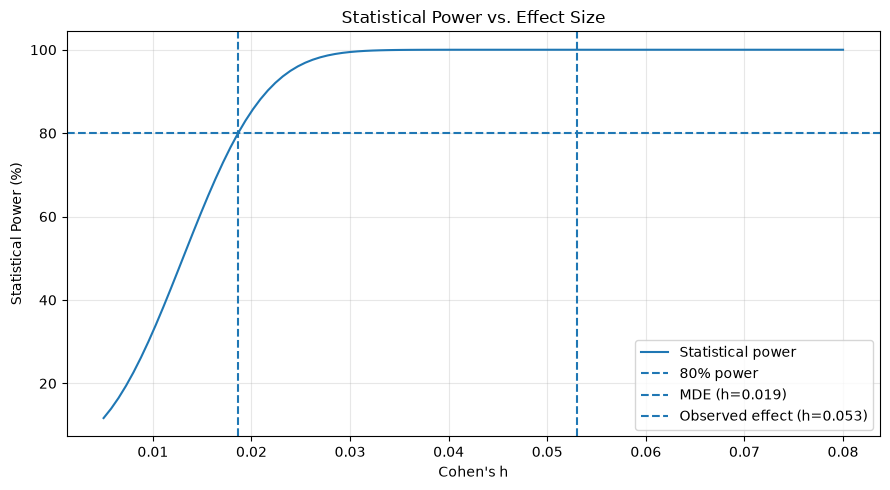

In [39]:
import matplotlib.pyplot as plt

# Plot statistical power against effect size
plt.figure(figsize=(9, 5))

plt.plot(
    effect_sizes,
    np.array(powers) * 100,
    label="Statistical power"
)

# 80% power threshold
plt.axhline(
    80,
    linestyle="--",
    label="80% power"
)

# Minimum detectable effect
plt.axvline(
    mde_h,
    linestyle="--",
    label=f"MDE (h={mde_h:.3f})"
)

# Observed effect
plt.axvline(
    effect_h,
    linestyle="--",
    label=f"Observed effect (h={effect_h:.3f})"
)

plt.xlabel("Cohen's h")
plt.ylabel("Statistical Power (%)")
plt.title("Statistical Power vs. Effect Size")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Power Curve Interpretation

The power curve shows that statistical power increases rapidly as the true effect size increases.

The estimated MDE corresponds to a Cohen's h of approximately **0.019**, where statistical power reaches 80%.

The observed effect has a Cohen's h of approximately **0.053**, which is substantially larger than the MDE. This explains why the observed effect is detected with very high statistical power given the available sample size.

The analysis also shows that the experiment was capable of detecting relatively modest improvements in conversion rate, not only effects as large as the observed difference.

# 10. Experimental Allocation & Sample Ratio Check

The treatment and control groups are highly imbalanced.

Before interpreting the A/B test as a valid randomized experiment, we need to determine whether the observed allocation is consistent with a plausible intended allocation.

We will first document the observed allocation and then test it against a clearly stated expected allocation.

In [40]:
# Observed allocation
allocation_summary = (
    df["test group"]
    .value_counts()
    .rename("users")
    .to_frame()
)

allocation_summary["share"] = (
    allocation_summary["users"]
    / allocation_summary["users"].sum()
)

allocation_summary["share_pct"] = (
    allocation_summary["share"] * 100
)

allocation_summary

,users,share,share_pct
test group,,,
ad,564577,0.96,96.000007
psa,23524,0.04,3.999993


### Allocation Results

The observed allocation is highly unbalanced:

* **Ad:** 564,577 users (approximately 96%)
* **PSA:** 23,524 users (approximately 4%)

This means the experiment does not use an equal 50/50 allocation. The PSA group is substantially smaller than the advertising group.

The imbalance is important when interpreting the experiment because the smaller control group provides less information for estimating the control conversion rate and can affect the efficiency of the experiment.

The statistical analysis therefore considers not only the observed conversion difference, but also its confidence interval, effect size, and statistical power.


In [41]:
# Hypothetical 50/50 allocation
total_users = len(df)

expected_50_50 = np.array([
    total_users * 0.50,
    total_users * 0.50
])

observed_counts = np.array([
    n_treatment,
    n_control
])

print("Observed counts:")
print(observed_counts)

print("\nExpected counts under 50/50:")
print(expected_50_50)

Observed counts:
[564577  23524]

Expected counts under 50/50:
[294050.5 294050.5]


### Allocation Comparison

Under a hypothetical 50/50 allocation, each group would contain approximately 294,051 users.

The observed experiment instead contains approximately 564,577 advertising users and 23,524 PSA users.

The observed allocation differs substantially from the hypothetical 50/50 allocation, with most users assigned to the advertising group.


In [52]:
from scipy.stats import chisquare

# Chi-square goodness-of-fit test for 50/50 allocation
allocation_test = chisquare(
    f_obs=observed_counts,
    f_exp=expected_50_50
)

print(f"Chi-square statistic: {allocation_test.statistic:.2f}")
print(f"p-value: {allocation_test.pvalue:.4e}")

Chi-square statistic: 497768.83
p-value: 0.0000e+00


The chi-square goodness-of-fit test evaluates whether the observed allocation is consistent with a hypothetical 50/50 split. Given the large difference between the observed and expected group sizes, the allocation is not consistent with a 50/50 design.

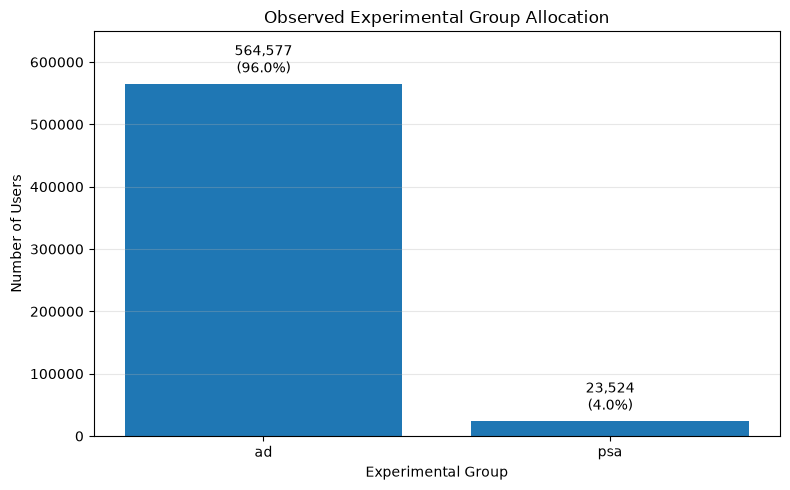

In [59]:
import matplotlib.pyplot as plt

groups = allocation_summary.index
users = allocation_summary["users"]
shares = allocation_summary["share_pct"]

plt.figure(figsize=(8, 5))

bars = plt.bar(groups, users)

plt.xlabel("Experimental Group")
plt.ylabel("Number of Users")
plt.title("Observed Experimental Group Allocation")

# Add labels above bars with some spacing
for bar, user_count, share in zip(bars, users, shares):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(users) * 0.02,
        f"{user_count:,}\n({share:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Give labels enough room above the bars
plt.ylim(0, max(users) * 1.15)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Allocation Interpretation

The experiment is highly unbalanced, with approximately 96% of users in the advertising group and 4% in the PSA control group.

This differs substantially from an idealized 50/50 allocation.

The imbalance does not prevent the two-proportion test from being performed, but it is important when interpreting statistical power and experiment efficiency. The large treatment sample provides substantial precision for estimating the advertising conversion rate, while the much smaller control group is the limiting group for comparison.
The unequal allocation should therefore be considered when interpreting statistical power, precision, and the representativeness of the control comparison.

Therefore, statistical significance should be interpreted alongside the effect size, confidence interval, and practical business impact rather than relying on the p-value alone.

## 11. Time-Based Experiment Stability

An A/B test assumes that treatment and control outcomes are comparable over the experiment period.

We therefore examine conversion rates by day of week to determine whether the treatment effect is broadly consistent across different weekdays.

In [43]:
# Conversion rate by day and experimental group

daily_conversion = (
    df.groupby(["most ads day", "test group"])["converted"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "users",
        "sum": "conversions",
        "mean": "conversion_rate"
    })
)

daily_conversion["conversion_rate_pct"] = (
    daily_conversion["conversion_rate"] * 100
)

daily_conversion

,most ads day,test group,users,conversions,conversion_rate,conversion_rate_pct
0,Friday,ad,88805,1995,0.022465,2.246495
1,Friday,psa,3803,62,0.016303,1.630292
2,Monday,ad,83571,2778,0.033241,3.324120
3,Monday,psa,3502,79,0.022559,2.255854
4,Saturday,ad,78802,1679,0.021307,2.130657
5,Saturday,psa,2858,40,0.013996,1.399580
6,Sunday,ad,82332,2027,0.024620,2.461983
7,Sunday,psa,3059,63,0.020595,2.059497
8,Thursday,ad,79077,1711,0.021637,2.163714
9,Thursday,psa,3905,79,0.020230,2.023047


## 11.1 Daily Treatment Effects

We compare the treatment and control conversion rates within each day.

The daily absolute lift is calculated as:

Treatment conversion rate − Control conversion rate

This helps assess whether the overall treatment effect is directionally consistent across the experiment period.

In [54]:
# Put treatment and control conversion rates side by side
daily_rates = (
    daily_conversion
    .pivot(
        index="most ads day",
        columns="test group",
        values="conversion_rate"
    )
    .reset_index()
)

# Calculate daily absolute and relative lift
daily_rates["absolute_lift"] = (
    daily_rates["ad"] - daily_rates["psa"]
)

daily_rates["absolute_lift_pp"] = (
    daily_rates["absolute_lift"] * 100
)

daily_rates["relative_lift_pct"] = (
    daily_rates["absolute_lift"]
    / daily_rates["psa"]
    * 100
)

daily_rates["lift_direction"] = np.where(
    daily_rates["absolute_lift"] > 0,
    "Positive",
    "Negative"
)
daily_rates

test group,most ads day,ad,psa,absolute_lift,absolute_lift_pp,relative_lift_pct,lift_direction
0,Friday,0.022465,0.016303,0.006162,0.616203,37.797113,Positive
1,Monday,0.033241,0.022559,0.010683,1.068266,47.355277,Positive
2,Saturday,0.021307,0.013996,0.007311,0.731076,52.235413,Positive
3,Sunday,0.024620,0.020595,0.004025,0.402487,19.542962,Positive
4,Thursday,0.021637,0.020230,0.001407,0.140666,6.953197,Positive
5,Tuesday,0.030440,0.014448,0.015992,1.599250,110.690914,Positive
6,Wednesday,0.025356,0.015759,0.009597,0.959655,60.894460,Positive


## 11.2 Conversion Rate by Day

The following chart compares treatment and control conversion rates across the seven days represented in the dataset.

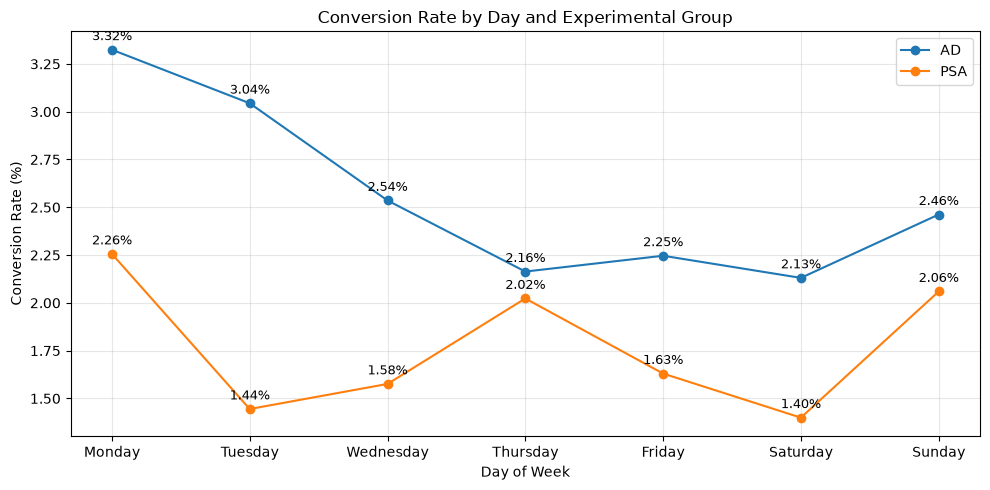

In [55]:
plt.figure(figsize=(10, 5))

for group in ["ad", "psa"]:
    group_data = plot_data[
        plot_data["test group"] == group
    ]

    plt.plot(
        group_data["most ads day"],
        group_data["conversion_rate_pct"],
        marker="o",
        label=group.upper()
    )

    # Add value labels
    for x, y in zip(
        group_data["most ads day"],
        group_data["conversion_rate_pct"]
    ):
        plt.text(
            x,
            y + 0.05,
            f"{y:.2f}%",
            ha="center",
            fontsize=9
        )

plt.xlabel("Day of Week")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Day and Experimental Group")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11.3 Ad Exposure and Conversion

The dataset records the total number of ads each user saw.

We examine conversion rates across exposure bands as an observational analysis. This is useful for understanding user behavior, but it should not be interpreted as causal evidence because ad exposure itself was not randomly assigned.

In [46]:
# Create ad exposure bands

df["ad_exposure_band"] = pd.cut(
    df["total ads"],
    bins=[0, 5, 10, 20, 50, 100, np.inf],
    labels=[
        "1-5",
        "6-10",
        "11-20",
        "21-50",
        "51-100",
        "100+"
    ],
    include_lowest=True
)

exposure_summary = (
    df.groupby("ad_exposure_band", observed=False)["converted"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "users",
        "sum": "conversions",
        "mean": "conversion_rate"
    })
)

exposure_summary["conversion_rate_pct"] = (
    exposure_summary["conversion_rate"] * 100
)

exposure_summary

,ad_exposure_band,users,conversions,conversion_rate,conversion_rate_pct
0,1-5,177823,449,0.002525,0.252498
1,6-10,82952,409,0.004931,0.493056
2,11-20,127484,1070,0.008393,0.839321
3,21-50,130776,3774,0.028859,2.885851
4,51-100,46002,5242,0.113952,11.395157
5,100+,23064,3899,0.169051,16.905134


## 11.4 Conversion Rate by Ad Exposure

Conversion rate increases substantially across observed ad-exposure bands.

Although conversion rates increase substantially with observed ad exposure, this relationship is descriptive rather than causal. Users were not randomly assigned to exposure levels, so factors such as user engagement or campaign targeting may also contribute to the observed relationship.

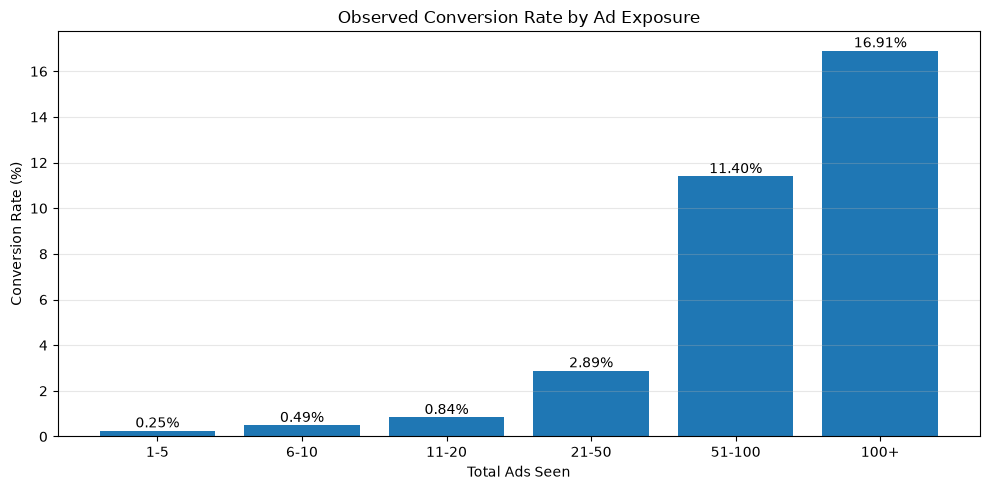

In [57]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    exposure_summary["ad_exposure_band"].astype(str),
    exposure_summary["conversion_rate_pct"]
)

plt.xlabel("Total Ads Seen")
plt.ylabel("Conversion Rate (%)")
plt.title("Observed Conversion Rate by Ad Exposure")

for bar, value in zip(
    bars,
    exposure_summary["conversion_rate_pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
exposure_by_group = pd.crosstab(
    df["ad_exposure_band"],
    df["test group"],
    normalize="columns"
) * 100

exposure_by_group

test group,ad,psa
ad_exposure_band,,
1-5,30.104308,33.416936
6-10,14.087892,14.517089
11-20,21.845382,17.641558
21-50,22.236294,22.253868
51-100,7.819837,7.877062
100+,3.906287,4.293488


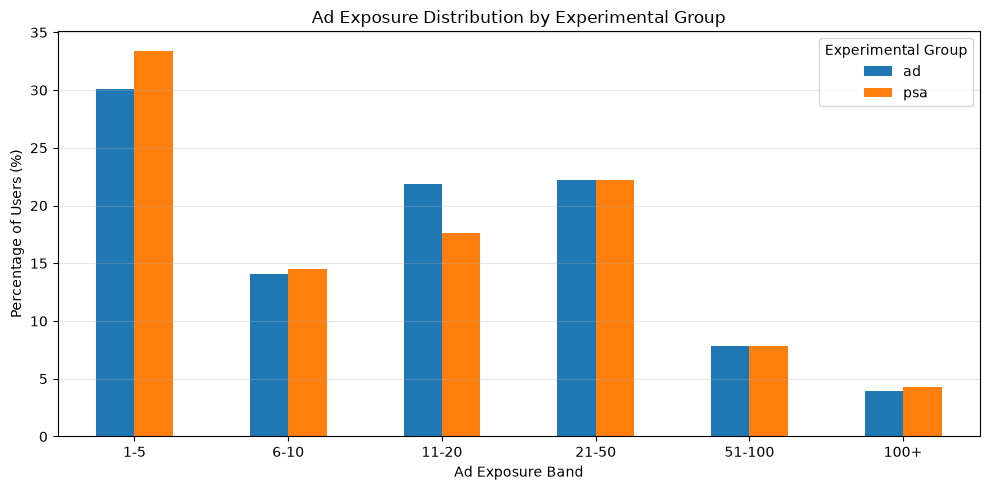

In [58]:
exposure_by_group.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Ad Exposure Band")
plt.ylabel("Percentage of Users (%)")
plt.title("Ad Exposure Distribution by Experimental Group")
plt.xticks(rotation=0)
plt.legend(title="Experimental Group")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 12. Final A/B Test Results

The primary experiment compares conversion between the Ad treatment group and the PSA control group.

The analysis reports the observed conversion rates, absolute treatment effect, relative lift, confidence interval, hypothesis-test result, and effect-size measures.

In [60]:
# Final A/B test results - presentation-ready summary

final_results = pd.DataFrame({
    "Metric": [
        "Control conversion rate",
        "Treatment conversion rate",
        "Absolute lift",
        "Relative lift",
        "95% confidence interval",
        "P-value",
        "Estimated statistical power",
        "MDE at 80% power"
    ],
    "Result": [
        f"{p_control:.2%}",
        f"{p_treatment:.2%}",
        f"{observed_difference * 100:.3f} percentage points",
        f"{relative_lift:.2f}%",
        f"[{ci_lower * 100:.3f}, {ci_upper * 100:.3f}] percentage points",
        "< 0.001" if p_value_library < 0.001 else f"{p_value_library:.4f}",
        f"{power:.1%}",
        f"{mde_relative_lift:.2f}% relative lift"
    ]
})

final_results

,Metric,Result
0,Control conversion rate,1.79%
1,Treatment conversion rate,2.55%
2,Absolute lift,0.769 percentage points
3,Relative lift,43.09%
4,95% confidence interval,"[0.595, 0.943] percentage points"
5,P-value,< 0.001
6,Estimated statistical power,100.0%
7,MDE at 80% power,14.30% relative lift


### Final Interpretation

The treatment group had a conversion rate of **2.55%**, compared with **1.79%** in the control group.

The observed absolute improvement was **0.769 percentage points**, corresponding to a **43.09% relative lift**.

The 95% confidence interval for the absolute treatment effect ranges from **0.595 to 0.943 percentage points**. Because the entire interval is above zero, the estimated treatment effect is positive under the assumptions of the analysis.

The hypothesis test produced a **p-value below 0.001**, providing strong statistical evidence against the null hypothesis of equal conversion rates.

The estimated statistical power is approximately **100%**, while the minimum detectable effect at 80% power corresponds to approximately **14.30% relative lift** under the specified assumptions.

Statistical significance should be considered alongside the effect size, confidence interval, experimental allocation, and practical business impact.

### Supporting Statistical Measures

The following measures provide additional context for the magnitude and interpretation of the treatment effect.

In [62]:
supporting_stats = pd.DataFrame({
    "Metric": [
        "Risk ratio",
        "Odds ratio",
        "Cohen's h",
        "Statistical power"
    ],
    "Value": [
        f"{risk_ratio:.4f}",
        f"{odds_ratio:.4f}",
        f"{effect_h:.4f}",
        f"{power:.1%}"
    ]
})

supporting_stats

,Metric,Value
0,Risk ratio,1.4309
1,Odds ratio,1.4421
2,Cohen's h,0.0530
3,Statistical power,100.0%


# 13. Statistical Conclusion

The Ad treatment group had a higher observed conversion rate than the PSA control group.

The observed conversion rate was **2.555%** for the Ad group compared with **1.785%** for the PSA group, corresponding to an absolute difference of **0.769 percentage points** and a relative lift of **43.09%**.

A two-sided two-proportion z-test produced a z-statistic of **7.37** and a p-value below **0.001**. This provides strong statistical evidence against the null hypothesis of equal conversion rates under the assumptions of the test.

The 95% confidence interval for the treatment effect was **[0.595, 0.943] percentage points**. The interval lies entirely above zero, indicating that the estimated treatment effect is positive within the uncertainty captured by the interval.

The standardized effect size, measured using Cohen's h, was **0.053**, indicating a relatively small standardized effect. However, the absolute conversion improvement of **0.769 percentage points** is the more directly interpretable measure for this business context.

The experiment had very high estimated statistical power. The minimum detectable effect at 80% power corresponds to approximately **14.3% relative lift** under the assumptions used in the power analysis.

The treatment group also had a higher observed conversion rate on each of the seven days represented in the dataset, providing directional consistency with the overall result.

However, the experimental allocation was highly unbalanced, with approximately **96% of users in the Ad group and 4% in the PSA control group**. This imbalance should be considered when assessing experiment efficiency and interpreting the results.

The ad-exposure analysis showed a strong observational relationship between the number of ads seen and conversion. Because ad exposure was not itself randomly assigned, this relationship should not be interpreted as causal evidence that increasing ad frequency causes higher conversion.

# 14. Business Recommendation

The observed results support **further consideration of the Ad treatment**, but a full rollout should be preceded by additional experiment-quality and business-impact checks.

The Ad group achieved a **2.555% conversion rate** compared with **1.785%** for the PSA control group, corresponding to an absolute improvement of **0.769 percentage points** and a relative lift of **43.09%**. The 95% confidence interval for the absolute improvement was **[0.595, 0.943] percentage points**, and the hypothesis test produced a p-value below **0.001**.

The treatment effect was directionally consistent across all seven days in the dataset, which provides additional descriptive support for the overall finding.

However, the experiment had a highly unequal allocation of approximately **96% Ad users versus 4% PSA users**. A follow-up experiment with a clearly defined and appropriately randomized allocation would provide a stronger basis for making a rollout decision.

Before full deployment, the marketing team should also evaluate:

- **Incremental revenue:** whether the additional conversions generate sufficient economic value.
- **Campaign cost:** whether the incremental conversions justify the cost of advertising.
- **User experience:** whether increased advertising creates negative effects such as ad fatigue.
- **Experiment quality:** whether the treatment and control groups were assigned according to the intended randomization procedure.
- **Longer-term impact:** whether the observed conversion improvement persists beyond the measured experiment period.

The ad-exposure analysis should not be used to justify simply increasing ad frequency. The relationship between exposure and conversion is observational because exposure was not randomly assigned, so it does not establish that higher exposure itself causes higher conversion.